<a href="https://colab.research.google.com/github/lakshmi772/lakshmi772/blob/main/Machine_Learning_Task_HR_Attrition_Prediction_(Classification).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**HR Attrition Prediction**

#**Problem Statement**

The goal of this project is to develop a classification model that predicts whether an employee will leave the company (Attrition: Yes/No).

The dataset contains employee details such as:

Age
Salary
Job Role
Job Satisfaction
Work Experience
Overtime
Work-Life Balance
Department

The objective is to classify:

1 → Attrition (Employee will leave)
0 → No Attrition (Employee will stay)

#**Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#**Load Data**

In [ ]:
data = pd.read_csv('/content/telecom_churn_data (1).csv')
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


#**Basic Checks**

In [ ]:
data.shape

(7043, 21)

In [ ]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes


In [ ]:
data.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7038 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7041 non-null   object 


In [ ]:
data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
num_data = data.select_dtypes(include=['int64','float64'])
num_data

,SeniorCitizen,tenure,MonthlyCharges
0,0,1,29.85
1,0,34,56.95
2,0,2,53.85
3,0,45,42.30
4,0,2,70.70
...,...,...,...
7038,0,24,84.80
7039,0,72,103.20
7040,0,11,29.60
7041,1,4,74.40


In [ ]:
cat_data = data.select_dtypes(include=['object'])
cat_data

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
0,7590-VHVEG,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,5575-GNVDE,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,1889.5,No
2,3668-QPYBK,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,108.15,Yes
3,7795-CFOCW,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),1840.75,No
4,9237-HQITU,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,NaN,Electronic check,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,1990.5,No
7039,2234-XADUH,Female,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),7362.9,No
7040,4801-JZAZL,Female,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,346.45,No
7041,8361-LTMKD,Male,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,306.6,Yes


In [ ]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7041.000000
mean,0.162147,32.371149,64.749581
std,0.368612,24.559481,30.085731
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
data.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7038,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7041,7043,7038,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6526,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3550,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4169,2365,11,5174


#**Data Cleaning**

#Missing Values

In [ ]:
data.isnull().sum()

,0
customerID,0
gender,5
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


There are no missing values

#Duplicates

In [ ]:
data.duplicated().sum()

np.int64(0)

There are no duplicates

#**Exploratory Data Analysis**

#Distribution of Attrition

In [ ]:
plt.figure(figsize=(5,2))
sns.countplot(x='hurn', data=data)
plt.show()

ValueError: Could not interpret value `Attrition` for `x`. An entry with this name does not appear in `data`.

<Figure size 500x200 with 0 Axes>

#Insights
* Shows number of employees who left vs stayed

* Usually dataset is imbalanced (more "No" than "Yes")

#Distribution of Age

In [ ]:
plt.figure(figsize=(5,2))
sns.histplot(data, x='Age', kde=True, color='green')
plt.show()

#Insights

* Most employees are in mid-age range
* Younger employees may show higher attrition

#Distribution of Monthly Income

In [ ]:
plt.figure(figsize=(5,2))
sns.histplot(data, x='MonthlyIncome', kde=True, color='green')
plt.show()

#Insights

* Most employees fall in lower to mid salary range
* High salary employees are fewer

#Distribution of Job Role

In [ ]:
plt.figure(figsize=(5,2))
sns.countplot(data=data, x='JobRole')
plt.xticks(rotation=45)
plt.show()

#Insights

* Sales Executive has the highest number of employees
* Research and technical roles also have large counts
* HR and managerial roles have fewer employees
* Workforce is mainly concentrated in sales and technical department

#Distribution of Overtime

In [ ]:
plt.figure(figsize=(5,2))
sns.countplot(data=data, x='OverTime')
plt.show()

#Insights

* Employees doing overtime are not  experience higher stress
* Possible relation with attrition

#Distribution of Work-Life Balance

In [ ]:
plt.figure(figsize=(5,2))
sns.countplot(data=data, x='WorkLifeBalance')
plt.show()

#Insights

* Most employees have work-life balance level 3 (good)
* Very few employees have poor balance (level 1)
* Moderate number of employees fall in levels 2 and 4
* Overall work-life balance in the company is satisfactory

#Bivariate Analysis

#Attrition vs Overtime

In [ ]:
plt.figure(figsize=(5,2))
sns.countplot(x='OverTime', hue='Attrition', data=data)
plt.show()

#Attrition vs Job Satisfaction

In [ ]:
plt.figure(figsize=(5,2))
sns.countplot(x='JobSatisfaction', hue='Attrition', data=data)
plt.show()

#Insights

* Low satisfaction → High attrition
* Important factor

#Attrition vs Monthly Income

In [ ]:
plt.figure(figsize=(5,2))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=data)
plt

#Insights

* Employees with lower income tend to leave more
* Salary plays a key role

#Attrition vs Age

In [ ]:
plt.figure(figsize=(5,2))
sns.boxplot(x='Attrition', y='Age', data=data)
plt.show()


#Insights

* Younger employees show higher attrition
* Experienced employees tend to stay

#Attrition vs Department

In [ ]:
plt.figure(figsize=(5,2))
sns.countplot(x='Department', hue='Attrition', data=data)
plt.xticks(rotation=45)
plt.show()

#Correlation Heatmap

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(data.corr(numeric_only=True), cmap='coolwarm')
plt.show()

#Insights

* Most features show weak correlation with each other
* MonthlyIncome is positively related to JobLevel and TotalWorkingYears
* Experience-related features (YearsAtCompany, YearsInCurrentRole, YearsWithCurrManager) are strongly correlated
* No strong negative correlations are observed

#**Key Insights Summary**
* Overtime has strong impact on attrition
* Low job satisfaction increases attrition
* Lower salary employees leave more
* Younger employees show higher attrition
* Work-life balance plays an important role

#**Conclusion**

EDA helped identify key factors influencing employee attrition.
Important variables include:

* Overtime
* Job Satisfaction
* Monthly Income
* Work-Life Balance

The dataset is suitable for building classification models.

#**Recommendations**
* Reduce employee overtime
* Improve job satisfaction programs
* Offer competitive salaries
* Promote work-life balance policies
* Focus on high-risk departments

#**Outlier Detection**

In [ ]:
num_cols = data.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(4,2))
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

Outliers are in MonthlyIncome,NumCompaniesWorked,PerformanceRating,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager

#Check Distribution

In [ ]:
cols = [
    'MonthlyIncome','NumCompaniesWorked','PerformanceRating',
    'StockOptionLevel','TotalWorkingYears','TrainingTimesLastYear',
    'YearsAtCompany','YearsInCurrentRole',
    'YearsSinceLastPromotion','YearsWithCurrManager'
]
for col in cols:
    plt.figure(figsize=(4,2))
    sns.histplot(data[col], kde=True)
    plt.title(col)
    plt.show()

#Skewness

In [ ]:
for col in cols:
  print(col,':',data[col].skew())

In [ ]:
cols = [
    'MonthlyIncome','NumCompaniesWorked','PerformanceRating',
    'StockOptionLevel','TotalWorkingYears','TrainingTimesLastYear',
    'YearsAtCompany','YearsInCurrentRole',
    'YearsSinceLastPromotion','YearsWithCurrManager'
]

for col in cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = data[(data.loc[:,col]>upper_limit)|(data.loc[:,col]<lower_limit)]

    percent = len(data[(data.loc[:,col]>upper_limit)|(data.loc[:,col]<lower_limit)])/len(data)*100

    print(f"Column: {col}")
    print(f"Outlier :{percent}")
    print("-"*50)

In [ ]:
cols = [
    'NumCompaniesWorked',
    'TotalWorkingYears',
    'YearsInCurrentRole',
    'YearsWithCurrManager'

]
for col in cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    median = data[col].median()

    data.loc[
        (data[col] > upper_limit) | (data[col] < lower_limit),
        col
    ] = median

In [ ]:
cols = [
    'MonthlyIncome','NumCompaniesWorked','PerformanceRating',
    'StockOptionLevel','TotalWorkingYears','TrainingTimesLastYear',
    'YearsAtCompany','YearsInCurrentRole',
    'YearsSinceLastPromotion','YearsWithCurrManager'
]

for col in cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = data[(data.loc[:,col]>upper_limit)|(data.loc[:,col]<lower_limit)]

    percent = len(data[(data.loc[:,col]>upper_limit)|(data.loc[:,col]<lower_limit)])/len(data)*100

    print(f"Column: {col}")
    print(f"Outlier :{percent}")
    print("-"*50)

#**Encoding**

In [ ]:
cat_data.columns

In [ ]:
cat_data

#Label Encoding Columns

Apply label encoding (mapping) to:

Attrition → Yes / No

Gender → Male / Female

OverTime → Yes / No

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data.loc[:,'Attrition']=le.fit_transform(data.loc[:,'Attrition'])
data.loc[:,'Gender']=le.fit_transform(data.loc[:,'Gender'])
data.loc[:,'OverTime']=le.fit_transform(data.loc[:,'OverTime'])

In [ ]:
data['Attrition'] = data['Attrition'].astype(int)
data['Gender'] = data['Gender'].astype(int)
data['OverTime'] = data['OverTime'].astype(int)

In [ ]:
data.dtypes

#One-Hot Encoding

Apply One-Hot Encoding to:

BusinessTravel

Department

EducationField

JobRole

MaritalStatus

In [ ]:
data = pd.get_dummies(data,columns=['BusinessTravel','Department','EducationField','JobRole','MaritalStatus'],drop_first=True)
data

#**feature selection**

In [ ]:
cols_to_drop = ['Over18', 'EmployeeCount', 'StandardHours', 'EmployeeNumber']

data.drop(cols_to_drop, axis=1, inplace=True)

#**Split data**

In [ ]:
x=data.drop(columns='Attrition')
y=data.loc[:,'Attrition']

#**Split data for Training and Testing**

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

#**Balance data**

In [ ]:
#check whether data is balanced or not
#plot countplot for target
plt.figure(figsize=(5,2))
sns.countplot(data,x='Attrition')

In [ ]:
print(y_train.unique())
print(y_train.dtype)

In [ ]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [ ]:
#smote
from imblearn.over_sampling import SMOTE
from collections import Counter
smote=SMOTE(random_state=42)
x_sampled,y_sampled=smote.fit_resample(x_train,y_train)
#balancing should be done on only train data

In [ ]:
#before balancing
Counter(y)

In [ ]:
Counter(y_sampled)

In [ ]:
data

#**Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

continuous_cols = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate',
    'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
    'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear',
    'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

scaler = StandardScaler()

# Copy data to avoid SettingWithCopyWarning
x_train_scaled = x_sampled.copy()
x_test_scaled = x_test.copy()

# Fit on train sampled and transform
x_train_scaled[continuous_cols] = scaler.fit_transform(x_train_scaled[continuous_cols])

# Only transform on test data
x_test_scaled[continuous_cols] = scaler.transform(x_test_scaled[continuous_cols])

#**Model Bulding**

In [ ]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_sampled,y_sampled)

In [ ]:
# Model predictions
y_pred =model.predict(x_test)

**Evaluating the model**

-confusion martix

-accuracy

-recall

-precision

-f1 score

-auc-roc curve

-log loss

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,f1_score,roc_auc_score,roc_curve

In [ ]:
confusion_matrix(y_test,y_pred)

In [ ]:
accuracy_score(y_test,y_pred)

In [ ]:
precision_score(y_test,y_pred)

In [ ]:
recall_score(y_test,y_pred)

In [ ]:
f1_score(y_test,y_pred)

In [ ]:
y_prob=model.predict_proba(x_test)[:,1]
#convert 2d array to 1d array
y_prob

In [ ]:
roc_auc_score(y_test,y_prob)

#**KNN Classifier**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors =5)
model.fit(x_sampled,y_sampled)#training
y_pred=model.predict(x_test)#testing

In [ ]:
#confusion matrix
confusion_matrix(y_test,y_pred)

In [ ]:
#accuracy
accuracy_score(y_test,y_pred)

In [ ]:
#recall
recall_score(y_test,y_pred)

In [ ]:
#precision
precision_score(y_test,y_pred)

In [ ]:
#f1 score
f1_score(y_test,y_pred)

In [ ]:
roc_auc_score(y_test,y_prob)

#**Decision Tree Classifier**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()#criterion='gini',splitter='best',max_features='sqrt',min_samples_split=5,min_samples_leaf=3
model.fit(x_sampled,y_sampled)
y_pred=model.predict(x_test)

In [ ]:
#confusion matrix
confusion_matrix(y_test,y_pred)

In [ ]:
#accuracy
accuracy_score(y_test,y_pred)

In [ ]:
#recall
recall_score(y_test,y_pred)

In [ ]:
#precision
precision_score(y_test,y_pred)

In [ ]:
#f1 score
f1_score(y_test,y_pred)

In [ ]:
#roc_auc_score
roc_auc_score(y_test,y_pred)

#**Cross Validation**

#**K fold**

In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
model=DecisionTreeClassifier(criterion='gini',splitter='best',max_features='sqrt',min_samples_split=5,min_samples_leaf=3)
kfold=KFold(n_splits=5,shuffle=True,random_state=42)
scores=cross_val_score(model,x_sampled,y_sampled,cv=kfold)

In [ ]:
scores

In [ ]:
print(np.mean(scores))

#**Startified K fold**

In [ ]:
from sklearn.model_selection import StratifiedKFold
model=DecisionTreeClassifier(criterion='gini',splitter='best',max_features='sqrt',min_samples_split=5,min_samples_leaf=3)
sfold=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scores=cross_val_score(model,x_sampled,y_sampled,cv=sfold)

In [ ]:
scores

In [ ]:
print(np.mean(scores))

#**Random forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=10,max_depth=6,max_features=5,bootstrap=True,min_samples_split=5,min_samples_leaf=3)
model.fit(x_sampled,y_sampled)
y_pred=model.predict(x_test)

In [ ]:
confusion_matrix(y_test,y_pred)

In [ ]:
accuracy_score(y_test,y_pred)

In [ ]:
recall_score(y_test,y_pred)

In [ ]:
precision_score(y_test,y_pred)

In [ ]:
f1_score(y_test,y_pred)

In [ ]:
roc_auc_score(y_test,y_pred)

#**Gradient Boosting Classifier**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
model=GradientBoostingClassifier()
model.fit(x_sampled,y_sampled)
y_pred=model.predict(x_test)

In [ ]:
confusion_matrix(y_test,y_pred)

In [ ]:
accuracy_score(y_test,y_pred)

In [ ]:
recall_score(y_test,y_pred)

In [ ]:
precision_score(y_test,y_pred)

In [ ]:
f1_score(y_test,y_pred)

In [ ]:
roc_auc_score(y_test,y_pred)

#**XGBOOST Classifier**

In [ ]:
from xgboost import XGBClassifier
model=XGBClassifier()
model.fit(x_sampled,y_sampled)

In [ ]:
confusion_matrix(y_test,y_pred)

In [ ]:
accuracy_score(y_test,y_pred)

In [ ]:
recall_score(y_test,y_pred)

In [ ]:
precision_score(y_test,y_pred)

In [ ]:
f1_score(y_test,y_pred)

In [ ]:
roc_auc_score(y_test,y_pred)

#**Hyper parameter tuning**

In [ ]:
#gradient boosting
#grid search cv
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
model=GradientBoostingClassifier()
parameters={'max_depth':[3,5,6],'n_estimators':[100,200,300],'learning_rate':[0.01,0.2,0.3]}
grid_search=GridSearchCV(model,parameters,cv=5)
grid_search.fit(x_sampled,y_sampled)

In [ ]:
print(grid_search.best_params_)

In [ ]:
model=GradientBoostingClassifier(learning_rate=0.3,max_depth=6,n_estimators=300)
model.fit(x_sampled,y_sampled)
y_pred=model.predict(x_test)

In [ ]:
accuracy_score(y_test,y_pred)

In [ ]:
recall_score(y_test,y_pred)

In [ ]:
precision_score(y_test,y_pred)

In [ ]:
f1_score(y_test,y_pred)

In [ ]:
roc_auc_score(y_test,y_pred)

#**Randomized Search CV**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
model=GradientBoostingClassifier()
parameters={'max_depth':[3,5,6],'n_estimators':[100,200,300],'learning_rate':[0.01,0.2,0.3]}
random=RandomizedSearchCV(estimator=model,param_distributions=parameters,cv=5,n_iter=20)
random.fit(x_sampled,y_sampled)

In [ ]:
print(random.best_params_)

In [ ]:
model=GradientBoostingClassifier(learning_rate=0.2,max_depth=6,n_estimators=200)
model.fit(x_sampled,y_sampled)
y_pred=model.predict(x_test)

In [ ]:
accuracy_score(y_test,y_pred)

In [ ]:
recall_score(y_test,y_pred)

In [ ]:
precision_score(y_test,y_pred)

In [ ]:
f1_score(y_test,y_pred)

In [ ]:
roc_auc_score(y_test,y_pred)

#**XGBOOST**

In [ ]:
#grid search
from xgboost import XGBClassifier
model=XGBClassifier()
parameters={'max_depth':[3,5,6],'n_estimators':[100,200,300],'learning_rate':[0.01,0.2,0.3],'reg_alpha':[0.1,0.01],'reg_lambda':[0.01,0.2,0.3]}
grid_search=GridSearchCV(model,parameters,cv=5)
grid_search.fit(x_sampled,y_sampled)

In [ ]:
print(grid_search.best_params_)

In [ ]:
model=XGBClassifier(learning_rate=0.2, max_depth= 5, n_estimators= 300,reg_alpha =0.1,reg_lambda= 0.3)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [ ]:
accuracy_score(y_test,y_pred)

In [ ]:
recall_score(y_test,y_pred)

In [ ]:
precision_score(y_test,y_pred)

In [ ]:
f1_score(y_test,y_pred)

In [ ]:
roc_auc_score(y_test,y_pred)

In [ ]:
#randomized search
from xgboost import XGBClassifier
model=XGBClassifier()
parameters={'max_depth':[3,5,6],'n_estimators':[100,200,300],'learning_rate':[0.01,0.2,0.3],'reg_alpha':[0.1,0.01],'reg_lambda':[0.01,0.2,0.3]}
random=RandomizedSearchCV(model,param_distributions=parameters,cv=5,n_iter=20)
random.fit(x_sampled,y_sampled)

In [ ]:
print(random.best_params_)

In [ ]:
model=XGBClassifier(reg_lambda=0.01,reg_alpha= 0.01,n_estimators= 300, max_depth= 6, learning_rate= 0.3)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [ ]:
accuracy_score(y_test,y_pred)

In [ ]:
recall_score(y_test,y_pred)

In [ ]:
precision_score(y_test,y_pred)

In [ ]:
f1_score(y_test,y_pred)

In [ ]:
roc_auc_score(y_test,y_pred)

#**Support Vector Classifier**

In [ ]:
from sklearn.svm import SVC
model=SVC()
model.fit(x_sampled,y_sampled)
y_pred=model.predict(x_test)

In [ ]:
confusion_matrix(y_test,y_pred)

In [ ]:
accuracy_score(y_test,y_pred)

In [ ]:
recall_score(y_test,y_pred)

In [ ]:
precision_score(y_test,y_pred)

In [ ]:
f1_score(y_test,y_pred)

In [ ]:
roc_auc_score(y_test,y_pred)

#**Grid Search**

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
model = SVC()
parameters = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': [0.1, 0.01, 0.001],
    'gamma': [0.1, 1, 5, 10]
}

grid = GridSearchCV(estimator=model, param_grid=parameters, cv=5, scoring='accuracy')
grid.fit(x_train_scaled, y_sampled)

In [ ]:
print(grid.best_params_)

In [ ]:
model=SVC(C=0.1,gamma=0.1,kernel='linear')
model.fit(x_sampled,y_sampled)
y_pred=model.predict(x_test)

In [ ]:
confusion_matrix(y_test,y_pred)

In [ ]:
accuracy_score(y_test,y_pred)

In [ ]:
recall_score(y_test,y_pred)

In [ ]:
precision_score(y_test,y_pred)

In [ ]:
f1_score(y_test,y_pred)

#**Random Search CV**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
model=SVC()
parameters={'kernel':['linear','poly','rbf','sigmoid'],'C':[0.1,0.01,0.001],'gamma':[0.1,1,5,10]}
random=RandomizedSearchCV(estimator=model,param_distributions=parameters,cv=5,scoring='accuracy',n_iter=10)
random.fit(x_train_scaled, y_sampled)

In [ ]:
print(random.best_params_)

In [ ]:
model=SVC(C=0.1,gamma=0.1,kernel='linear')
model.fit(x_sampled,y_sampled)
y_pred=model.predict(x_test)

In [ ]:
confusion_matrix(y_test,y_pred)

In [ ]:
accuracy_score(y_test,y_pred)

In [ ]:
recall_score(y_test,y_pred)

In [ ]:
precision_score(y_test,y_pred)

In [ ]:
f1_score(y_test,y_pred)

Model Comparison Table


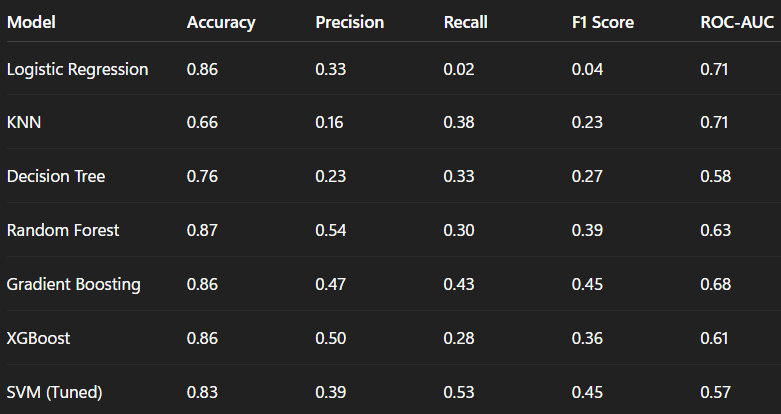

#20. Best Model Selection
Best Model: Gradient Boosting Classifier

Why?

* Balanced performance (not biased like Logistic)

* Good recall (~43%) ->important for attrition

* Good precision (~47%)

* Highest F1-score (~0.45)

In HR problem:

Recall is very important

(we want to catch employees who may leave)

So:

Gradient Boosting is the best practical model

#21. Final Insights & Business Recommendations

Key Insights

* OverTime
  Employees working overtime → more likely to leave
* Job Satisfaction
  Low satisfaction → high attrition
* Monthly Income
  Low salary → higher attrition
* Age
  Younger employees leave more
* Work-Life Balance
  Poor balance → higher attrition
* Experience Factors
  Employees with less experience → higher risk

#Business Recommendations
1. Reduce Overtime
Introduce workload balancing
Hire additional staff if needed
2. Improve Job Satisfaction
Employee engagement programs
Recognition & rewards
3. Salary Optimization
Competitive compensation
Performance-based incentives
4. Focus on Young Employees
Career growth plans
Mentorship programs
5. Improve Work-Life Balance
Flexible working hours
Remote work options
6. Retention Strategy
Identify high-risk employees using model
Take proactive actions

Among all models, Gradient Boosting performed the best with a balanced trade-off between precision and recall. The model successfully identifies employees at risk of attrition. Key drivers include overtime, job satisfaction, salary, and work-life balance. Organizations can use these insights to reduce attrition and improve employee retention.